In [25]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
!pip install kaggle

In [27]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"

In [28]:
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
face-mask-12k-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [29]:
import zipfile

with zipfile.ZipFile("face-mask-12k-images-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [30]:
train_dir = "dataset/Face Mask Dataset/Train"
val_dir   = "dataset/Face Mask Dataset/Validation"
test_dir  = "dataset/Face Mask Dataset/Test"

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [32]:
train_dir = "dataset/Face Mask Dataset/Train"
val_dir   = "dataset/Face Mask Dataset/Validation"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load Data

In [33]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names
print(class_names)

Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
['WithMask', 'WithoutMask']


# Normalize

In [34]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))


# Model (MobileNetV2)

In [35]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile

In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train

In [38]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9867 - loss: 0.0362 - val_accuracy: 0.9962 - val_loss: 0.0088
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9955 - loss: 0.0146 - val_accuracy: 0.9962 - val_loss: 0.0057
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9969 - loss: 0.0085 - val_accuracy: 0.9962 - val_loss: 0.0086
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9967 - loss: 0.0080 - val_accuracy: 0.9987 - val_loss: 0.0030
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9971 - loss: 0.0068 - val_accuracy: 0.9975 - val_loss: 0.0059
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9974 - loss: 0.0063 - val_accuracy: 0.9975 - val_loss: 0.0062
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 0.9975 - val_loss: 0.0037


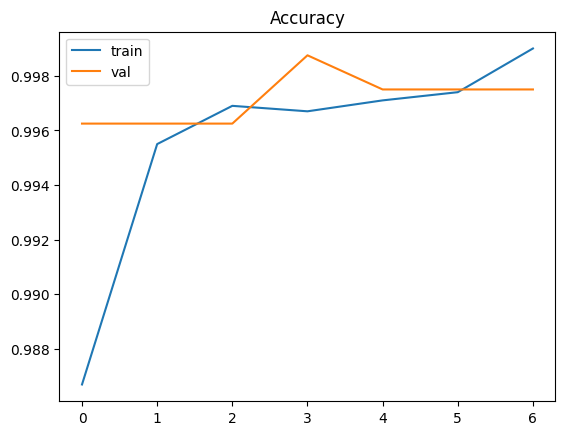

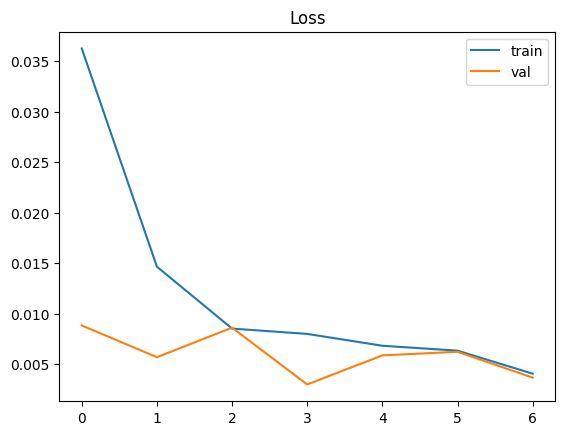

In [60]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()


#Save Model

In [40]:
model.save("face_mask_model.h5")

In [61]:
from google.colab import files
files.download("face_mask_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from tensorflow.keras.models import load_model

model = load_model("face_mask_model.h5")

In [42]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/Face Mask Dataset/Test",
    image_size=(224, 224),
    batch_size=32
)

test_data = test_data.map(lambda x, y: (x/255, y))

Found 992 files belonging to 2 classes.


In [43]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9980 - loss: 0.0062
Test Accuracy: 0.9979838728904724


In [58]:
from google.colab import files
uploaded = files.upload()

Saving test24.jfif to test24.jfif


In [59]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "test24.jfif"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = model.predict(img_array)
pred = prediction[0][0]

print("Raw prediction:", pred)

if pred > 0.75:
    print("Prediction: Without Mask ")
elif pred < 0.25:
    print("Prediction: With Mask ")
else:
    print("Prediction: Uncertain ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Raw prediction: 0.010436342
Prediction: With Mask 
